# Analyze results from phyloglm

In [25]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt

# Resolve repo root whether cwd is repo root, scripts/, or a stage subdirectory.
cwd = os.getcwd()
if os.path.basename(cwd) == "orb-selection":
    repo_root = cwd
elif os.path.basename(os.path.dirname(cwd)) == "orb-selection":
    repo_root = os.path.dirname(cwd)
elif os.path.basename(os.path.dirname(os.path.dirname(cwd))) == "orb-selection":
    repo_root = os.path.dirname(os.path.dirname(cwd))
else:
    repo_root = cwd

src_path = os.path.join(repo_root, "src")
stage04_path = os.path.join(repo_root, "scripts", "04_permulation_loss_dup")
for path in (src_path, stage04_path):
    if path not in sys.path:
        sys.path.insert(0, path)

results_path = os.path.join(repo_root, "results")

print(f"Using src path: {src_path}")
print(f"Using stage-04 path: {stage04_path}")

# Import modules
import odds_ratio_test as ort
from id_converter import convert_hogs_to_locs

%load_ext autoreload

Using src path: /Users/calvin/orb-selection/src
Using stage-04 path: /Users/calvin/orb-selection/scripts/04_permulation_loss_dup
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [61]:
loss_df = pd.read_csv(f"{results_path}/phyloglm_loss_qvals.csv", index_col="HOG")
dup_df = pd.read_csv(f"{results_path}/phyloglm_dup_qvals.csv", index_col="HOG")

In [64]:
loss_sig_pglm = loss_df[loss_df["qvalue"] < 0.05].sort_values("qvalue")
dup_sig_pglm = dup_df[dup_df["qvalue"] < 0.05].sort_values("qvalue")

print("Significant Loss HOGs by PhyloGLM:", loss_sig_pglm.shape[0])
print("Significant Duplication HOGs by PhyloGLM:", dup_sig_pglm.shape[0])

Significant Loss HOGs by PhyloGLM: 502
Significant Duplication HOGs by PhyloGLM: 23


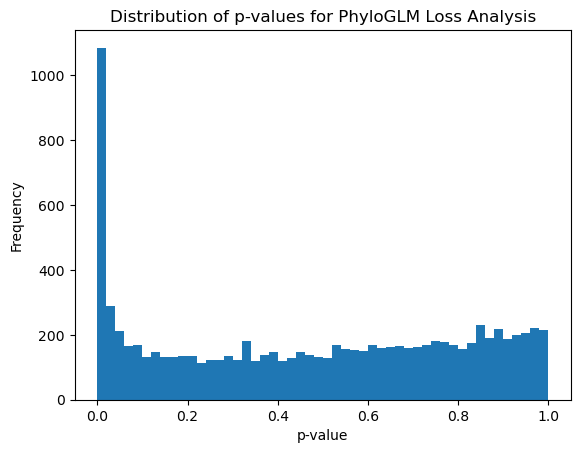

In [22]:
plt.hist(loss_df["coef_orb_weavingTRUE_p.value"], bins=50)
plt.title("Distribution of p-values for PhyloGLM Loss Analysis")
plt.xlabel("p-value")
plt.ylabel("Frequency")
plt.show()

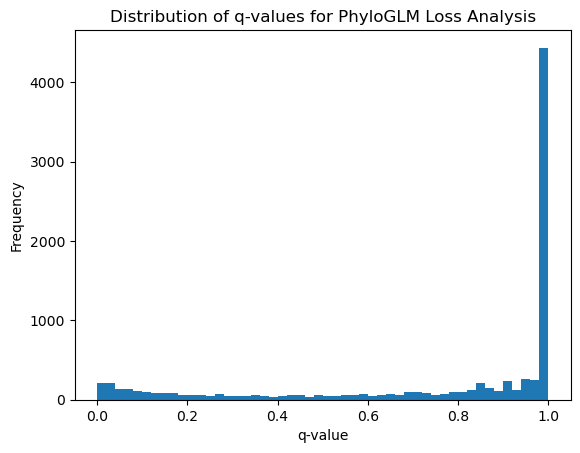

In [24]:
plt.hist(loss_df["qvalue"], bins=50)
plt.title("Distribution of q-values for PhyloGLM Loss Analysis")
plt.xlabel("q-value")
plt.ylabel("Frequency")
plt.show()

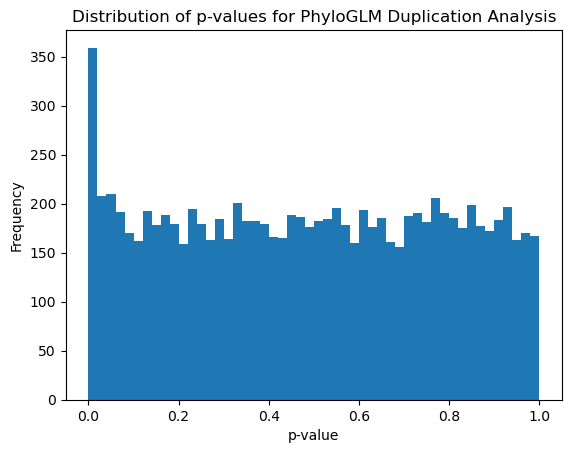

In [23]:
plt.hist(dup_df["coef_orb_weavingTRUE_p.value"], bins=50)
plt.title("Distribution of p-values for PhyloGLM Duplication Analysis")
plt.xlabel("p-value")
plt.ylabel("Frequency")
plt.show()

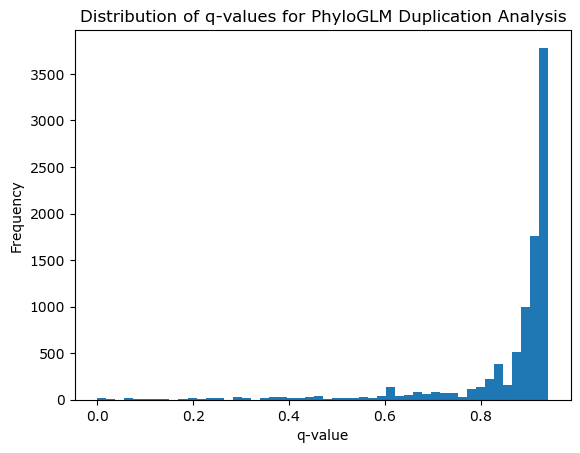

In [50]:
plt.hist(dup_df["qvalue"], bins=50)
plt.title("Distribution of q-values for PhyloGLM Duplication Analysis")
plt.xlabel("q-value")
plt.ylabel("Frequency")
plt.show()

In [65]:
%autoreload 2
results_all = ort.PermulationTestResults.load_from_pickle(
    "results/odds_ratio_test/Results_Apr16/Run1_occ_30-88_10000x_all_orb/results.pkl"
    )
_, counts1, run1_df, total_count1 = results_all.filter_for_permulation_hits()
run1_df

,Occupancy,Log odds ratio of loss,Log odds ratio of duplication,P-value loss more likely in fg,P-value loss more likely in bg,P-value duplication more likely in fg,P-value duplication more likely in bg,Significant by avgd thresholds,Significant by permulation
HOG,,,,,,,,,
N5.HOG0001041,46,2.2880419958817027,-0.2817346202540693,0.0038,0.9962,0.5328,0.4672,,loss_fg
N5.HOG0001609,49,-2.8415866828425416,2.3914853308298487,0.9605,0.0395,0.0747,0.9253,,loss_bg
N5.HOG0001627,33,2.048042501668181,-4.020456662035705,0.0449,0.9551,0.9745,0.0253,dup_bg,"loss_fg, dup_bg"
N5.HOG0002031,46,-3.8236010086737187,1.8546381292872387,0.9996,0.0004,0.3311,0.6686,loss_bg,loss_bg
N5.HOG0002072,52,3.473732866474442,-0.7627257209774443,0.0108,0.9892,0.7989,0.2011,loss_fg,loss_fg
...,...,...,...,...,...,...,...,...,...
N5.HOG0073114,36,1.3104432405070903,-1.2065338432852248,0.0218,0.9782,0.7961,0.2038,,loss_fg
N5.HOG0073157,34,-3.1863908889825234,1.988283912125373,0.9576,0.0424,0.1151,0.8846,loss_bg,loss_bg
N5.HOG0073180,32,-1.0380576659729286,0.7247318573436278,0.9929,0.0071,0.1394,0.8606,,loss_bg


In [66]:
loss_fg_sig_perm = run1_df[run1_df["Significant by permulation"].str.contains("loss_fg", na=False)]
loss_bg_sig_perm = run1_df[run1_df["Significant by permulation"].str.contains("loss_bg", na=False)]
dup_fg_sig_perm = run1_df[run1_df["Significant by permulation"].str.contains("dup_fg", na=False)]
dup_bg_sig_perm = run1_df[run1_df["Significant by permulation"].str.contains("dup_bg", na=False)]

print("Loss Foreground Significant by Permulation:", loss_fg_sig_perm.shape[0])
print("Loss Background Significant by Permulation:", loss_bg_sig_perm.shape[0])
print("Duplicate Foreground Significant by Permulation:", dup_fg_sig_perm.shape[0])
print("Duplicate Background Significant by Permulation:", dup_bg_sig_perm.shape[0])

Loss Foreground Significant by Permulation: 224
Loss Background Significant by Permulation: 529
Duplicate Foreground Significant by Permulation: 429
Duplicate Background Significant by Permulation: 383


In [67]:
loss_fg_sig_perm_thresh = loss_fg_sig_perm[loss_fg_sig_perm["Significant by avgd thresholds"].str.contains("loss_fg", na=False)].shape[0]
loss_bg_sig_perm_thresh = loss_bg_sig_perm[loss_bg_sig_perm["Significant by avgd thresholds"].str.contains("loss_bg", na=False)].shape[0]
dup_fg_sig_perm_thresh = dup_fg_sig_perm[dup_fg_sig_perm["Significant by avgd thresholds"].str.contains("dup_fg", na=False)].shape[0]
dup_bg_sig_perm_thresh = dup_bg_sig_perm[dup_bg_sig_perm["Significant by avgd thresholds"].str.contains("dup_bg", na=False)].shape[0]

print("Loss Foreground Significant by Permulation and Thresholds:", loss_fg_sig_perm_thresh)
print("Loss Background Significant by Permulation and Thresholds:", loss_bg_sig_perm_thresh)
print("Duplicate Foreground Significant by Permulation and Thresholds:", dup_fg_sig_perm_thresh)
print("Duplicate Background Significant by Permulation and Thresholds:", dup_bg_sig_perm_thresh)


Loss Foreground Significant by Permulation and Thresholds: 52
Loss Background Significant by Permulation and Thresholds: 217
Duplicate Foreground Significant by Permulation and Thresholds: 141
Duplicate Background Significant by Permulation and Thresholds: 86


In [68]:
dup_fg_sig_pglm = dup_sig_pglm[dup_sig_pglm["coef_orb_weavingTRUE_Estimate"] > 0]
dup_bg_sig_pglm = dup_sig_pglm[dup_sig_pglm["coef_orb_weavingTRUE_Estimate"] < 0]
loss_fg_sig_pglm = loss_sig_pglm[loss_sig_pglm["coef_orb_weavingTRUE_Estimate"] > 0]
loss_bg_sig_pglm = loss_sig_pglm[loss_sig_pglm["coef_orb_weavingTRUE_Estimate"] < 0]

print("Duplication Foreground Significant by PhyloGLM:", dup_fg_sig_pglm.shape[0])
print("Duplication Background Significant by PhyloGLM:", dup_bg_sig_pglm.shape[0])
print("Loss Foreground Significant by PhyloGLM:", loss_fg_sig_pglm.shape[0])
print("Loss Background Significant by PhyloGLM:", loss_bg_sig_pglm.shape[0])

Duplication Foreground Significant by PhyloGLM: 19
Duplication Background Significant by PhyloGLM: 4
Loss Foreground Significant by PhyloGLM: 291
Loss Background Significant by PhyloGLM: 211


In [74]:
overlap_loss_fg_df = loss_fg_sig_perm.merge(loss_fg_sig_pglm, left_index=True, right_index=True, suffixes=('_perm', '_pglm'))
overlap_loss_bg_df = loss_bg_sig_perm.merge(loss_bg_sig_pglm, left_index=True, right_index=True, suffixes=('_perm', '_pglm'))
overlap_dup_fg_df = dup_fg_sig_perm.merge(dup_fg_sig_pglm, left_index=True, right_index=True, suffixes=('_perm', '_pglm'))
overlap_dup_bg_df = dup_bg_sig_perm.merge(dup_bg_sig_pglm, left_index=True, right_index=True, suffixes=('_perm', '_pglm'))

print("Overlap Loss Foreground Significant by Both:", overlap_loss_fg_df.shape[0])
print("Overlap Loss Background Significant by Both:", overlap_loss_bg_df.shape[0])
print("Overlap Duplication Foreground Significant by Both:", overlap_dup_fg_df.shape[0])
print("Overlap Duplication Background Significant by Both:", overlap_dup_bg_df.shape[0])

Overlap Loss Foreground Significant by Both: 31
Overlap Loss Background Significant by Both: 73
Overlap Duplication Foreground Significant by Both: 7
Overlap Duplication Background Significant by Both: 1


In [79]:
loss_bg_locs = convert_hogs_to_locs(overlap_loss_bg_df, results_all.true_odds.hog_node_genes_tsv)["Description"].tolist()
print("Loss Background HOGs Significant by Both PhyloGLM and Permulation:", loss_bg_locs)


Processing HOGs:   0%|          | 0/73 [00:00<?, ?it/s]

Loss Background HOGs Significant by Both PhyloGLM and Permulation: ['piggyBac transposable element-derived protein 4-like', 'piggyBac transposable element-derived protein 4-like', nan, nan, 'uncharacterized LOC129230408', 'piggyBac transposable element-derived protein 4-like', nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, 'angiotensin-converting enzyme-like', 'angiotensin-converting enzyme-like', nan, nan, 'S-adenosylmethionine synthase-like', 'focal adhesion kinase 1-like', nan, nan, nan, 'uncharacterized PE-PGRS family protein PE_PGRS54-like', 'ras-like GTP-binding protein Rho1', 'ras-like GTP-binding protein rhoA', nan, 'rap1 GTPase-activating protein 1-like', nan, nan, 'SET domain binding factor', nan, nan, nan, nan, 'BCL9 domain-containing protein legless', 'BCL9 domain-containing protein legless', nan, 'ellipsoid body open', nan, nan, nan, nan, nan, 'uncharacterized LOC129224997', 'uncharacterized LOC129224996', nan, nan, nan, 'DNA excision repair pro